# Ecobici – Análisis de balanceo, disponibilidad y mantenimiento
 
## Objetivo del cuaderno
Este notebook documenta el flujo analítico usado para estudiar la operación de Ecobici desde una perspectiva de **business intelligence**. La lógica del análisis sigue la propuesta de la presentación del proyecto: entender el problema de desbalanceo de bicicletas entre estaciones, detectar patrones de uso y mantenimiento, localizar anomalías operativas y proponer acciones prescriptivas como pronóstico y rebalanceo.
 
## Problema de negocio
El dolor principal para el usuario no es únicamente la cantidad total de bicicletas del sistema, sino la **distribución espaciotemporal** del inventario. Una estación puede fallar en dos sentidos:
- llegar vacía y no ofrecer bicicletas para iniciar un viaje;
- llegar saturada y no ofrecer docks para terminar el viaje.
 
En ambos casos, la percepción del servicio cae. Por eso el análisis se centra en **balance**, **disponibilidad**, **mantenimiento** y **priorización operativa**.

## 1. Inventario, fuente y linaje de los datasets

 
1. **Fuente original**  
   Dataset descargado desde Ecobici.
   https://ecobici.cdmx.gob.mx/en/open-data/
   Del año 2024, se descargaron datos de los primeros 4 meses.
 
2. **Fuente operativa del proyecto**  
   Repositorio de Drive donde los datos ya estaban separados en varios CSV y desde donde fueron consumidos por el notebook.
   https://drive.google.com/file/d/1ooZRXvEW3PmQ77oor9DbqPsjGTLaC4z4/view?usp=sharing
   Este repositorio pertenece a Carlos Alberto López Figueroa.
 
 
### Inventario de archivos usados en este notebook
`station_data.csv` 
`least_balanced_stations.csv` 
`static_stations.csv` 
`eco_bici_trips.csv` 
`eco_bici_trips_s.csv`

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from statsmodels.tsa.statespace.sarimax import SARIMAX

from IPython.display import display

from ipywidgets import interact, widgets

sns.set_context('talk')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
station_data = pd.read_csv('data/station_data.csv')
least_balanced = pd.read_csv('data/least_balanced_stations.csv')
static_stations = pd.read_csv('data/static_stations.csv')
trips = pd.read_csv('data/ecobici_trips.csv')
trips_s = pd.read_csv('data/ecobici_trips_s.csv')

In [3]:
print("Station Data:", station_data.shape)
print("Least Balanced Stations:", least_balanced.shape)
print("Static Stations:", static_stations.shape)
print("Trips Data:", trips.shape)

Station Data: (259184, 12)
Least Balanced Stations: (167, 17)
Static Stations: (668, 12)
Trips Data: (7048905, 9)


In [4]:
print("Tipos de datos")
print("Station Data:", station_data.dtypes)

Tipos de datos
Station Data: timestamp                    object
station_id                    int64
num_bikes_available           int64
num_bikes_disabled            int64
num_docks_available           int64
num_docks_disabled            int64
is_installed                  int64
is_renting                    int64
is_returning                  int64
last_reported                object
eightd_has_available_keys      bool
is_charging                    bool
dtype: object


In [5]:
print("Least Balanced Stations:", least_balanced.dtypes)

Least Balanced Stations: station_id                          int64
balance_ratio                     float64
num_bikes_available               float64
num_docks_available               float64
external_id                        object
name                               object
short_name                         object
lat                               float64
lon                               float64
rental_methods                     object
capacity                            int64
electric_bike_surcharge_waiver       bool
is_charging                          bool
eightd_has_key_dispenser             bool
has_kiosk                            bool
lat_grid                          float64
lon_grid                          float64
dtype: object


In [6]:
print("Static Stations:", static_stations.dtypes)

Static Stations: station_id                          int64
external_id                        object
name                               object
short_name                         object
lat                               float64
lon                               float64
rental_methods                     object
capacity                            int64
electric_bike_surcharge_waiver       bool
is_charging                          bool
eightd_has_key_dispenser             bool
has_kiosk                            bool
dtype: object


## 2. Calidad del dato, limpieza y transformaciones
 
### Transformaciones realizadas sobre `station_data`
| Transformación | Motivo de negocio / técnico |
|---|---|
| Conversión de `timestamp` y `last_reported` a fecha-hora | Permitir agregaciones temporales y análisis por hora/día |
| Conversión de banderas booleanas (`is_installed`, `is_renting`, `is_returning`) | Homogeneizar el estado operativo |
| Creación de `date` | Analizar tendencias diarias |
| Creación de `hour` | Detectar patrones horarios y ventanas de demanda |
| Creación de `day_of_week` con orden lunes-domingo | Comparar comportamiento entre días sin perder orden lógico |
| Creación de `balance_ratio = bikes / (bikes + docks)` | Medir qué tan equilibrada está una estación |
| Creación de `capacity_est = bikes_available + bikes_disabled + docks_available + docks_disabled` | Estimar capacidad total observada cuando se requiere una referencia operativa |
 
 
### Decisiones de limpieza aplicadas en el notebook
En ambos casos, se tienen valores nulos y son pocos, entonces se retiran para el análisis.
- `station_data = station_data.dropna()`
- `trips = trips.dropna()`
 
### Transformaciones realizadas sobre viajes
| Transformación | Motivo |
|---|---|
| Construcción de `dt_retiro` y `dt_arribo` | Crear timestamps completos de retiro y arribo |
| Cálculo de `trip_duration` | Medir duración y detectar viajes atípicos |
| Filtro de duración entre 0 y 240 minutos | Limpiar errores evidentes y acotar outliers no útiles para el análisis operativo |
| Creación de `hour` y `day_of_week` sobre retiro | Analizar demanda por día y hora |
| Normalización de IDs en rutas (`split('-').str[0]`) | Homologar claves para unir con `static_stations` |

In [8]:
station_data['timestamp'] = pd.to_datetime(station_data['timestamp'], errors='coerce')
station_data['last_reported'] = pd.to_datetime(station_data['last_reported'], errors='coerce')

#Asegurar bools
for col in ['is_installed', '_isrenting', 'is_returning']:
    if col in station_data.columns:
        station_data[col] = station_data[col].astype(bool)

#Helper de tiempo
station_data['date'] = station_data['timestamp'].dt.date
station_data['hour'] = station_data['timestamp'].dt.hour
station_data['day_of_week'] = station_data['timestamp'].dt.day_name()

DoW_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
station_data['day_of_week'] = pd.Categorical(station_data['day_of_week'], categories=DoW_order, ordered=True)

#Viendo balance con bikes disponibles/(bikes disponibles+docks disponibles)
station_data['balance_ratio'] = station_data['num_bikes_available'] / (station_data['num_bikes_available'] + station_data['num_docks_available']).replace({0: np.nan})  # Evitar división por cero

#Capacidad estimada (bikes + docks)
station_data['capacity_est'] = (station_data['num_bikes_available'] + station_data['num_bikes_disabled'] + station_data['num_docks_available'] + station_data['num_docks_disabled'])


In [9]:
print("Vacíos")
print("Station Data:", station_data.isnull().sum())

Vacíos
Station Data: timestamp                       0
station_id                      0
num_bikes_available             0
num_bikes_disabled              0
num_docks_available             0
num_docks_disabled              0
is_installed                    0
is_renting                      0
is_returning                    0
last_reported                   0
eightd_has_available_keys       0
is_charging                     0
date                            0
hour                            0
day_of_week                     0
balance_ratio                5163
capacity_est                    0
dtype: int64


In [10]:
print("Least Balanced Stations:", least_balanced.isnull().sum())

Least Balanced Stations: station_id                        0
balance_ratio                     0
num_bikes_available               0
num_docks_available               0
external_id                       0
name                              0
short_name                        0
lat                               0
lon                               0
rental_methods                    0
capacity                          0
electric_bike_surcharge_waiver    0
is_charging                       0
eightd_has_key_dispenser          0
has_kiosk                         0
lat_grid                          0
lon_grid                          0
dtype: int64


In [11]:
print("Static Stations:", static_stations.isnull().sum())

Static Stations: station_id                        0
external_id                       0
name                              0
short_name                        0
lat                               0
lon                               0
rental_methods                    0
capacity                          0
electric_bike_surcharge_waiver    0
is_charging                       0
eightd_has_key_dispenser          0
has_kiosk                         0
dtype: int64


In [12]:
print("Trips Data:", trips.isnull().sum())

Trips Data: Genero_Usuario           18
Edad_Usuario             58
Bici                      0
Ciclo_Estacion_Retiro     0
Fecha_Retiro              0
Hora_Retiro               0
Ciclo_EstacionArribo      0
Fecha Arribo              0
Hora_Arribo               0
dtype: int64


In [13]:
station_data=station_data.dropna()

In [14]:
trips=trips.dropna()

## 3. Disponibilidad operativa de bicicletas y docks
 
### Pregunta de negocio
¿En qué momentos del día cae la disponibilidad de bicicletas o docks y, por lo tanto, aumenta el riesgo de una mala experiencia de usuario?
 
### Qué mide esta sección
- comportamiento promedio por hora;
- distribución entre estaciones;
- diferencia entre un problema sistémico y un problema concentrado en estaciones específicas.

Disponibilidad de bicis y docks

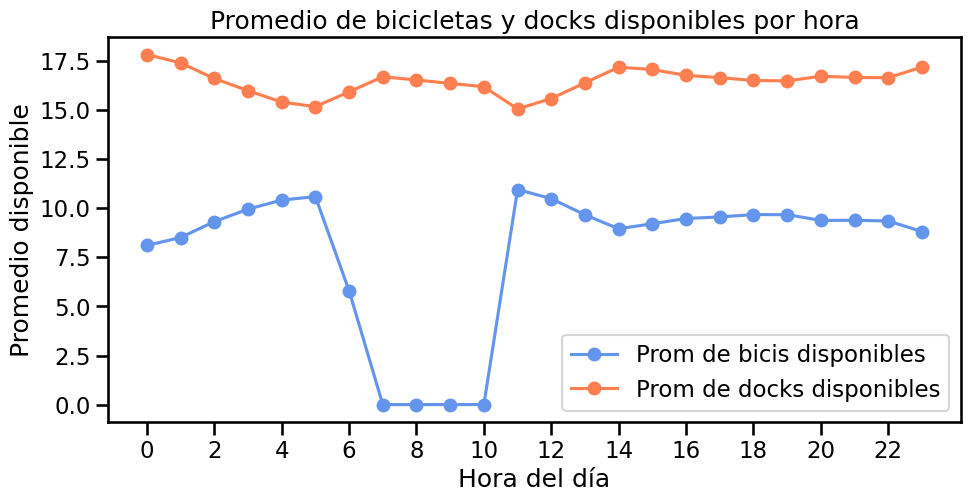

In [15]:
by_hour = (station_data.query('is_installed == True').groupby('hour')[['num_bikes_available', 'num_docks_available']].mean().reset_index())

plt.figure(figsize=(11, 5))
plt.plot(by_hour['hour'], by_hour['num_bikes_available'], label='Prom de bicis disponibles', marker='o', color='#6495ED')
plt.plot(by_hour['hour'], by_hour['num_docks_available'], label='Prom de docks disponibles', marker='o', color='#FF7F50')
plt.title('Promedio de bicicletas y docks disponibles por hora')
plt.xlabel('Hora del día')
plt.ylabel('Promedio disponible')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.show()

Distribución de bicicletas disponibles y docks por estaciones

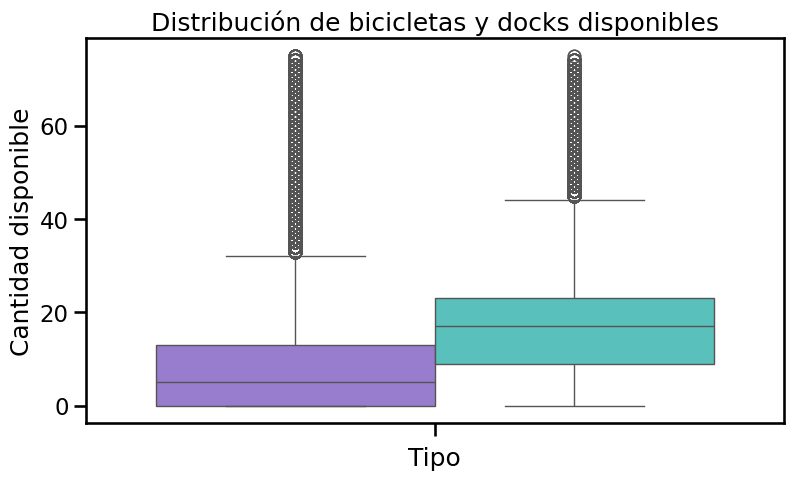

In [15]:
observaciones=station_data[['num_bikes_available', 'num_docks_available']].melt(var_name='tipo', value_name='cantidad')

plt.figure(figsize=(9, 5))
sns.boxplot(hue='tipo', y='cantidad', data=observaciones, palette=['#9370DB', '#48D1CC'], legend=False)
plt.title('Distribución de bicicletas y docks disponibles')
plt.xlabel('Tipo')
plt.ylabel('Cantidad disponible')
plt.show()

## 4. Mantenimiento y bicicletas deshabilitadas
 
### Pregunta de negocio
¿Dónde se concentra inventario no utilizable y qué estaciones merecen atención prioritaria de mantenimiento o recolección?
 
### Decisión metodológica importante
Para esta parte del análisis se **excluye la franja 00:00–05:00**. La razón es que la madrugada puede incluir mantenimiento, menor operación comercial o comportamientos atípicos que sesgan la comparación con el resto del día.

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/4187992116.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='num_bikes_disabled', y='station_id', data=top_disabled, palette='Reds_r', orient='h',order=top_disabled['station_id'])


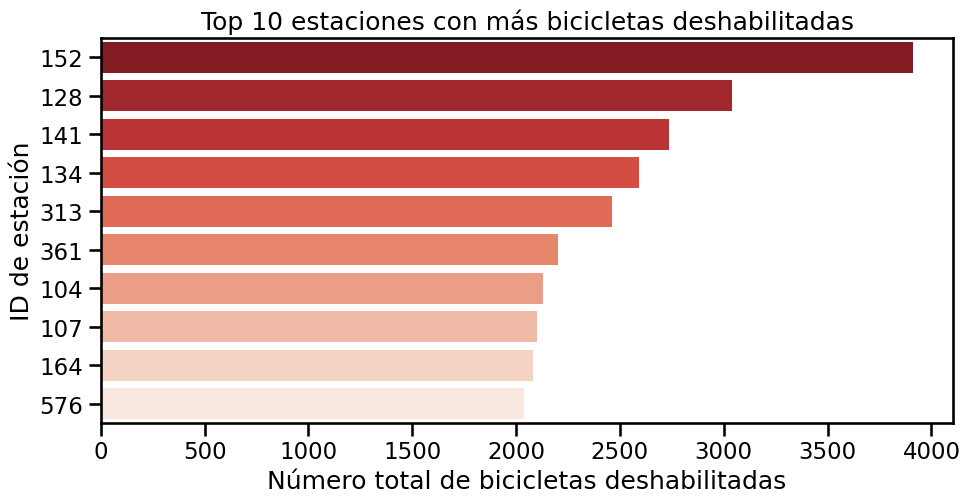

In [16]:
#Sin contar madrugada (0-5am) porque no sirve de mucho en el análisis
dia=station_data[station_data['hour'].between(5,23)].copy()

#Top
top=10

top_disabled=(dia.groupby('station_id')['num_bikes_disabled'].sum().sort_values(ascending=False).head(top).reset_index())

plt.figure(figsize=(11, 5))
sns.barplot(x='num_bikes_disabled', y='station_id', data=top_disabled, palette='Reds_r', orient='h',order=top_disabled['station_id'])
plt.title(f'Top {top} estaciones con más bicicletas deshabilitadas')
plt.xlabel('Número total de bicicletas deshabilitadas')
plt.ylabel('ID de estación')
plt.show()

Frecuencia de Bicicletas deshabilitadas por día de la semana

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/2422166615.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='num_bikes_disabled', data=DoW_disabled, palette='Blues_d')


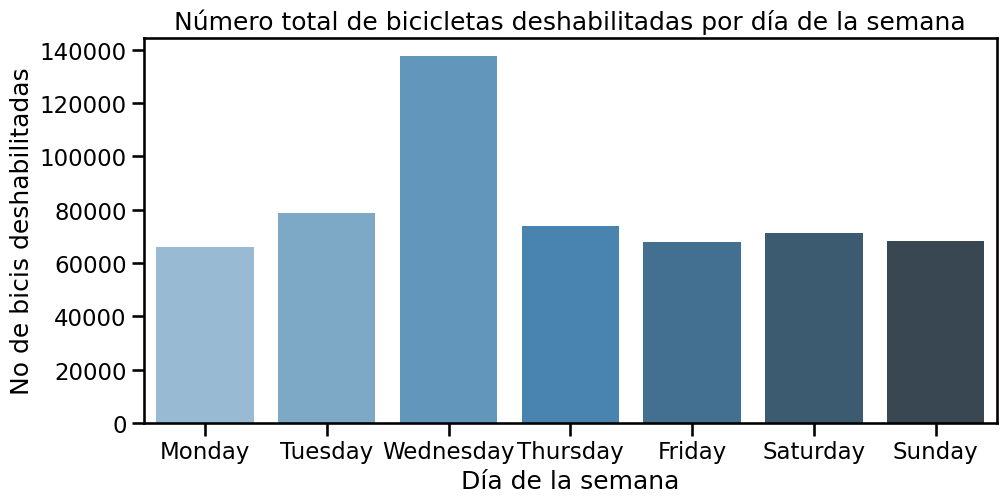

In [17]:
DoW_disabled=(station_data.groupby('day_of_week', observed=True)['num_bikes_disabled'].sum().reindex(DoW_order).reset_index())

plt.figure(figsize=(11, 5))
sns.barplot(x='day_of_week', y='num_bikes_disabled', data=DoW_disabled, palette='Blues_d')
plt.title('Número total de bicicletas deshabilitadas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('No de bicis deshabilitadas')
plt.show()

## 5. Tendencias temporales: disponibilidad, mantenimiento y balance
 
### Pregunta de negocio
¿Cómo evoluciona el sistema a lo largo del periodo observado y qué señales permiten distinguir un comportamiento estable de una degradación operativa?

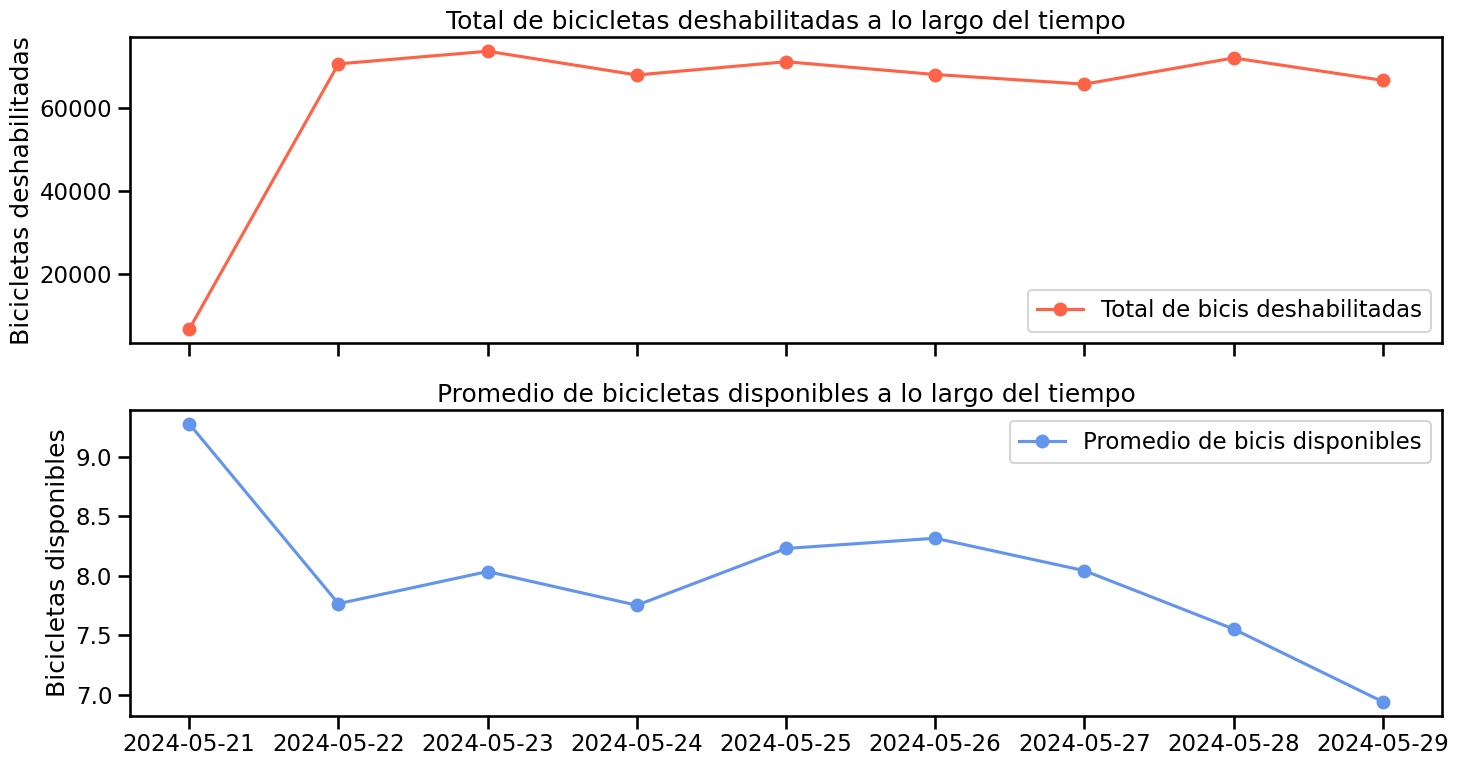

In [18]:
fecha=(station_data.groupby('date').agg(
    total_disabled=('num_bikes_disabled', 'sum'),
    avg_bikes_available=('num_bikes_available', 'mean'),
    avg_docks_available=('num_docks_available', 'mean'),
    avg_balance_ratio=('balance_ratio', 'mean')
).reset_index())

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax[0].plot(fecha['date'], fecha['total_disabled'], label='Total de bicis deshabilitadas', color='#FF6347', marker='o')
ax[0].set_title('Total de bicicletas deshabilitadas a lo largo del tiempo')
ax[0].set_ylabel('Bicicletas deshabilitadas')
ax[0].legend()
ax[1].plot(fecha['date'], fecha['avg_bikes_available'], label='Promedio de bicis disponibles', color='#6495ED', marker='o')
ax[1].set_title('Promedio de bicicletas disponibles a lo largo del tiempo')
ax[1].set_ylabel('Bicicletas disponibles')
ax[1].legend()

plt.tight_layout()
plt.show()

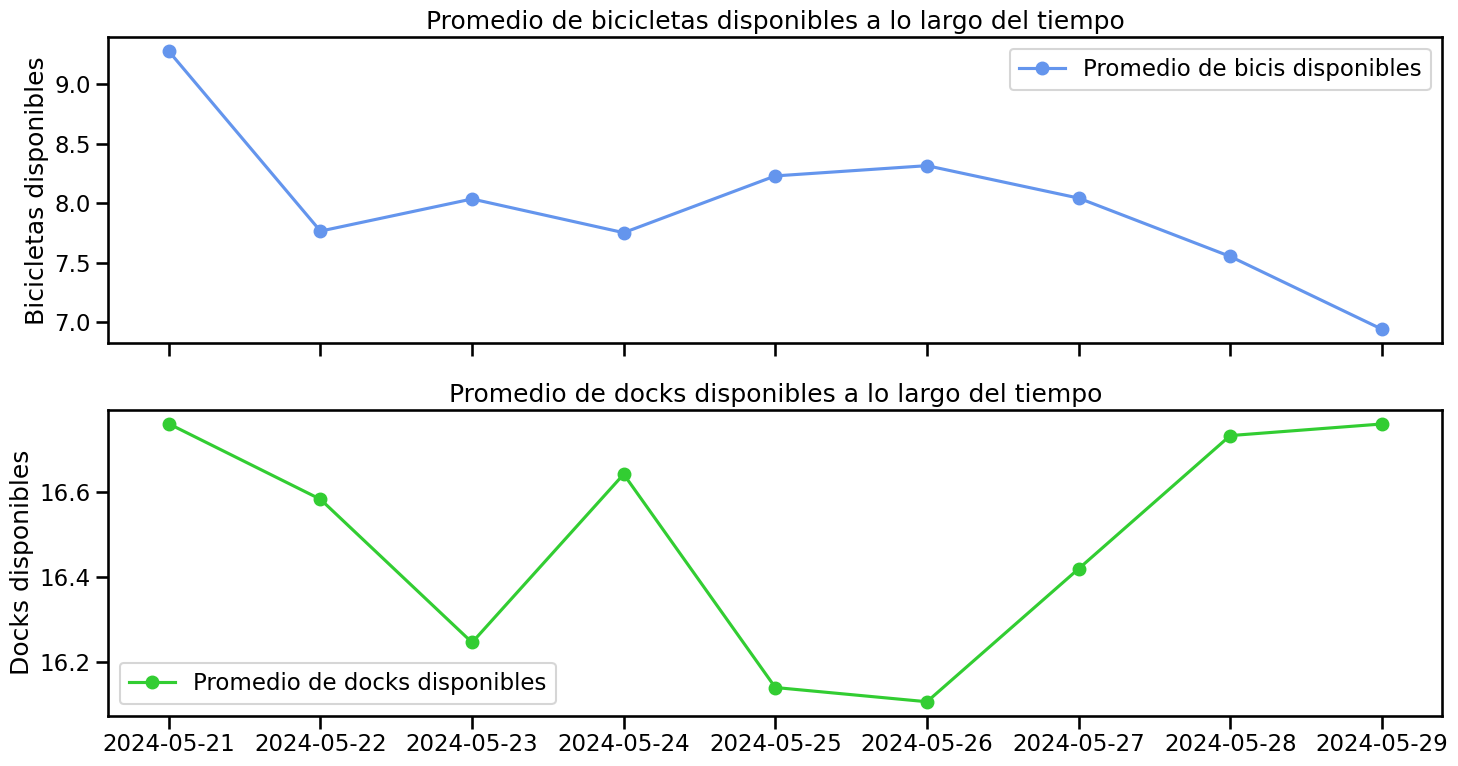

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax[0].plot(fecha['date'], fecha['avg_bikes_available'], label='Promedio de bicis disponibles', color='#6495ED', marker='o')
ax[0].set_title('Promedio de bicicletas disponibles a lo largo del tiempo')
ax[0].set_ylabel('Bicicletas disponibles')
ax[0].legend()
ax[1].plot(fecha['date'], fecha['avg_docks_available'], label='Promedio de docks disponibles', color='#32CD32', marker='o')
ax[1].set_title('Promedio de docks disponibles a lo largo del tiempo')
ax[1].set_ylabel('Docks disponibles')
ax[1].legend()

plt.tight_layout()
plt.show()

## 6. Balance de estaciones
 
### Cómo interpretar el balance
- Valores cercanos a **0**: estación tendencialmente vacía.
- Valores cercanos a **1**: estación tendencialmente saturada de bicicletas.
- Valores intermedios: mejor equilibrio entre retiro y devolución.
 

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/3276504880.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DoW_balance=(station_data.groupby('day_of_week')['balance_ratio'].mean().reindex(DoW_order).reset_index())


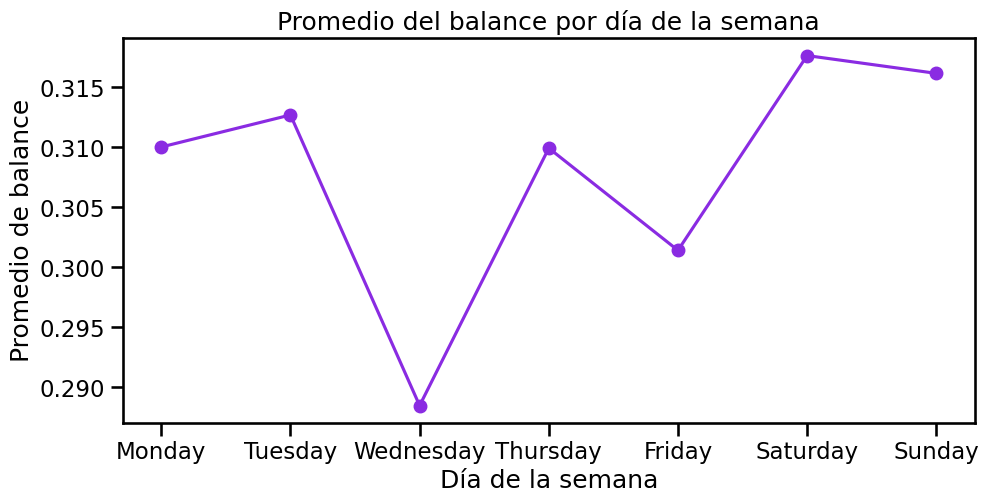

In [20]:
#bikes disponibles/(bikes disponibles+docks disponibles)
DoW_balance=(station_data.groupby('day_of_week')['balance_ratio'].mean().reindex(DoW_order).reset_index())

plt.figure(figsize=(11, 5))
plt.plot(DoW_balance['day_of_week'], DoW_balance['balance_ratio'], marker='o', color='#8A2BE2')
plt.title('Promedio del balance por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Promedio de balance')
plt.show()

## 7. Relación entre métricas operativas
 
### Pregunta de negocio
¿Las métricas del sistema se mueven juntas o responden a fenómenos distintos?
 
La matriz de correlación es útil para entender si mantenimiento y disponibilidad deben gestionarse como un solo problema o como frentes diferenciados.

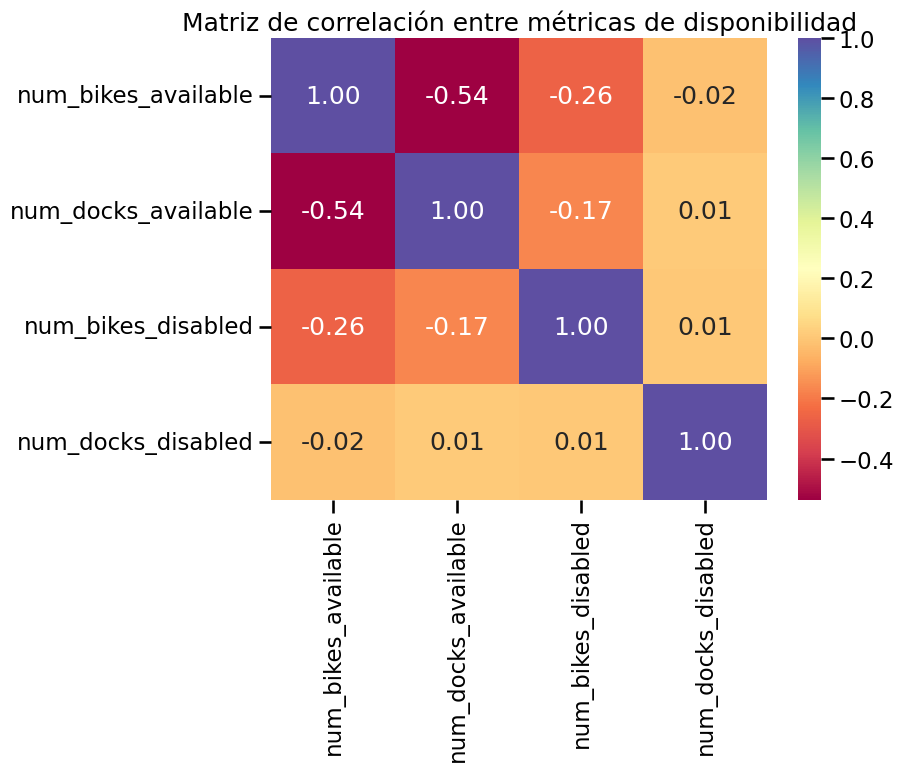

In [21]:
metricas = ['num_bikes_available', 'num_docks_available', 'num_bikes_disabled', 'num_docks_disabled']
cor = station_data[metricas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor, annot=True, cmap='Spectral', fmt=".2f")
plt.title('Matriz de correlación entre métricas de disponibilidad')
plt.show()

## 8. Geografía del problema
 
La dimensión espacial es indispensable porque el usuario experimenta el servicio en territorio. Una red puede estar “bien” en promedio y fallar en corredores muy concretos.

In [22]:
fig = px.scatter_mapbox(
    least_balanced, 
    lat='lat', lon='lon',
    color='balance_ratio',
    hover_name='name',
    hover_data={'station_id': True, 'balance_ratio': ':.3f', 'capacity':True},
    zoom=10,
    height=450,
    color_continuous_scale='RdYlGn',
    mapbox_style='carto-positron'
)

fig.update_layout(title='Estaciones con peor balance promedio', title_x=0.5)
fig.show()

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/1764774153.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 8.1 Estaciones menos balanceadas
 
**Qué muestra**
- El mapa localiza estaciones con peor balance promedio y permite ver si el desbalance está disperso o concentrado por zonas.
 
**Implicación**
- Si varias estaciones cercanas aparecen con mal balance, la solución no es intervenir una sola estación, sino diseñar políticas por **microzona** o corredor.

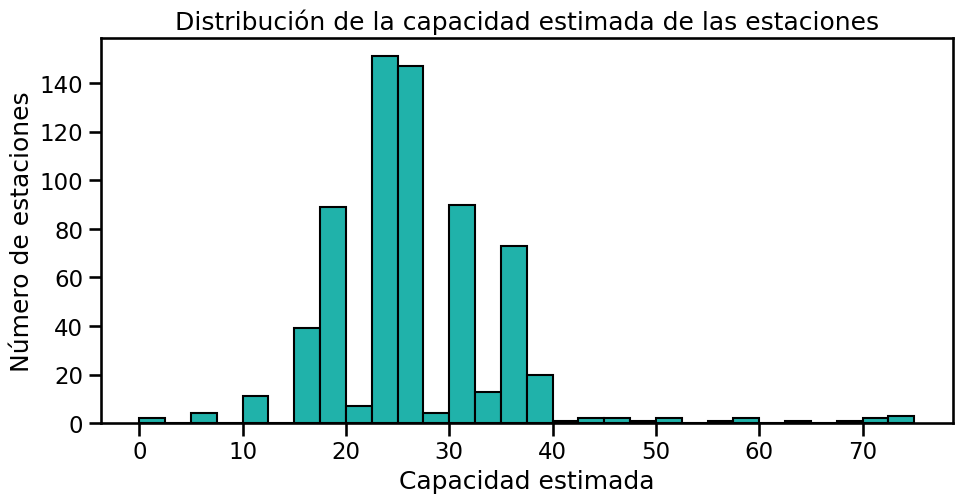

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_55119/2160269709.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [18]:
stations_geo = static_stations.copy() if static_stations is not None else least_balanced.copy()

need_cols= ['station_id', 'name', 'lat', 'lon']
for c in need_cols:
    if c not in stations_geo.columns:
        raise ValueError(f"Falta la columna '{c}' en los datos de estaciones")
stations_geo['station_id']=stations_geo['station_id'].astype(int)

plt.figure(figsize=(11, 5))
plt.hist(stations_geo['capacity'].dropna(), bins=30, color='#20B2AA', edgecolor='black')
plt.title('Distribución de la capacidad estimada de las estaciones')
plt.xlabel('Capacidad estimada')
plt.ylabel('Número de estaciones')
plt.show()

fig = px.scatter_mapbox(
    stations_geo, 
    lat='lat', lon='lon',
    color='capacity',
    size='capacity',
    hover_name='name',
    zoom=10,
    height=450,
    size_max=10,
    color_continuous_scale='RdYlGn',
    mapbox_style='carto-positron'
)
fig.update_layout(title='Capacidad estimada de las estaciones', title_x=0.5)
fig.show()

### 8.2 Capacidad de estaciones
 
**Qué muestra**
- La distribución de capacidad ayuda a entender la arquitectura de la red: muchas estaciones medianas, pocas muy grandes o viceversa.
- El mapa muestra qué zonas concentran la mayor capacidad instalada.
 
**Implicación**
- Las estaciones grandes tienen mayor criticidad operativa: un mal balance impacta a más usuarios.

In [19]:
disabled_by_station = station_data.groupby('station_id')['num_bikes_disabled'].sum().reset_index()

stations_disabled= stations_geo[['station_id', 'name', 'lat', 'lon']].merge(disabled_by_station, on='station_id', how='left')
stations_disabled['num_bikes_disabled'] = stations_disabled['num_bikes_disabled'].fillna(0)

top_stats_disabled=stations_disabled.sort_values('num_bikes_disabled', ascending=False).head(100)

fig = px.scatter_mapbox(
    top_stats_disabled, 
    lat='lat', lon='lon',
    color='num_bikes_disabled',
    size='num_bikes_disabled',
    hover_name='name',
    hover_data={'station_id': True, 'num_bikes_disabled': True},
    zoom=10,
    height=450,
    size_max=10,
    color_continuous_scale='RdYlGn',
    mapbox_style='carto-positron'
)
fig.update_layout(title='Top 100 estaciones con más bicicletas deshabilitadas', title_x=0.5)
fig.show()

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_55119/332729301.py:8: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 8.3 Geografía de bicicletas deshabilitadas
 
**Qué muestra**
- Permite ubicar clusters territoriales de mantenimiento.
 
**Implicación**
- Cuando varios hotspots se concentran en una ruta, conviene planear la operación de mantenimiento por zona y no solo por estación individual.

In [21]:
avg_bikes_station = station_data.groupby('station_id')['num_bikes_available'].mean().reset_index(name='avg_bikes_available')
stations_usage= stations_geo[['station_id', 'name', 'lat', 'lon']].merge(avg_bikes_station, on='station_id', how='left')

top_n = 100
low_usage = stations_usage.sort_values('avg_bikes_available', ascending=False).head(top_n)

fig = px.scatter_mapbox(
    low_usage, 
    lat='lat', lon='lon',
    color='avg_bikes_available',
    size='avg_bikes_available',
    hover_name='name',
    hover_data={'station_id': True, 'avg_bikes_available': ':.2f'},
    zoom=10,
    height=450,
    size_max=10,
    color_continuous_scale='RdYlGn_r',
    mapbox_style='carto-positron'
)
fig.update_layout(title=f'Top {top_n} estaciones con menor promedio de bicicletas disponibles', title_x=0.5)
fig.show()

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_55119/2580467274.py:7: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## 9. Viajes: duración y patrón horario de demanda
 
### Preguntas de negocio
- ¿Qué tan cortos o largos son los viajes?
- ¿En qué horas y días se concentra la demanda?
- ¿Qué comportamiento sugiere un uso de traslado cotidiano vs. recreativo?

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/1434089131.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  trips_s['dt_retiro'] = pd.to_datetime(trips_s['Fecha_Retiro'].astype(str) + ' ' + trips_s['Hora_Retiro'].astype(str), errors='coerce')
/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/1434089131.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  trips_s['dt_arribo'] = pd.to_datetime(trips_s['Fecha Arribo'].astype(str) + ' ' + trips_s['Hora_Arribo'].astype(str), errors='coerce')


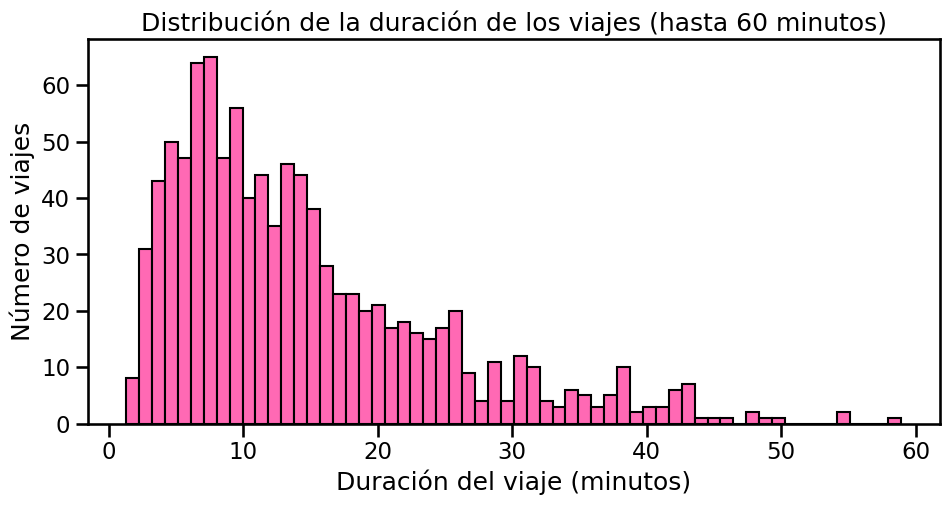

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/1434089131.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = trips_s.pivot_table(index='day_of_week', columns='hour', values='Bici', aggfunc='count').fillna(0)


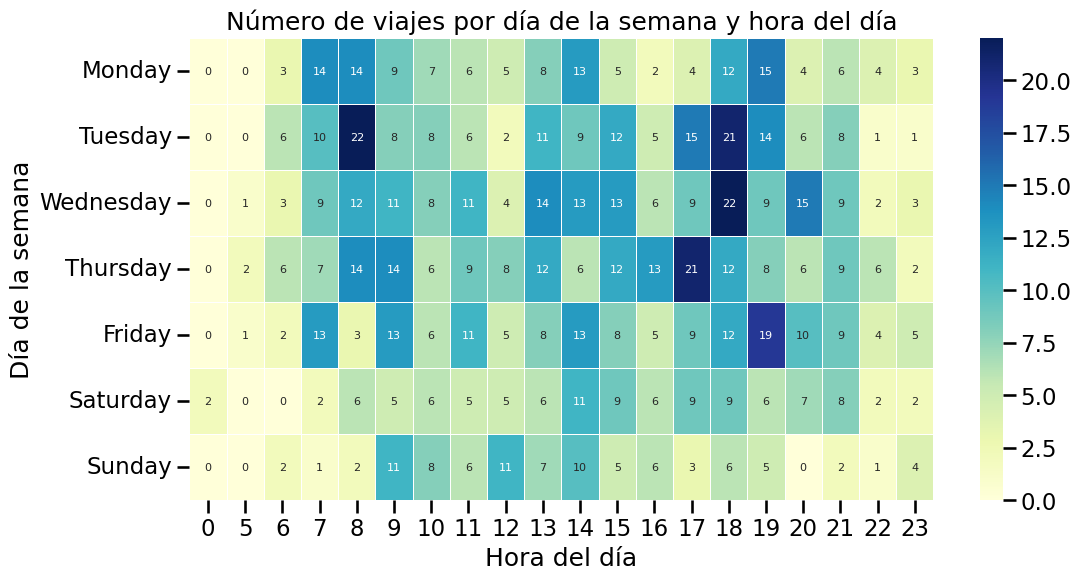

,dt_retiro,dt_arribo,trip_duration
0,2024-01-16 18:41:07,2024-01-16 18:55:47,14.666667
1,2024-02-07 19:21:41,2024-02-07 19:53:10,31.483333
2,2024-01-19 07:26:39,2024-01-19 07:37:56,11.283333
3,2024-04-07 18:10:51,2024-04-07 18:20:01,9.166667
4,2024-03-01 20:08:35,2024-03-01 20:21:15,12.666667


In [26]:
#Con un sample balanceado de 1000 filas para no saturar la memoria y para asegurarse que los datos estén limpios

trips_s['dt_retiro'] = pd.to_datetime(trips_s['Fecha_Retiro'].astype(str) + ' ' + trips_s['Hora_Retiro'].astype(str), errors='coerce')
trips_s['dt_arribo'] = pd.to_datetime(trips_s['Fecha Arribo'].astype(str) + ' ' + trips_s['Hora_Arribo'].astype(str), errors='coerce')

trips_s['trip_duration'] = (trips_s['dt_arribo'] - trips_s['dt_retiro']).dt.total_seconds() / 60  # Duración en minutos
trips_s = trips_s[(trips_s['trip_duration'] >= 0) & (trips_s['trip_duration'] <= 240)]

plt.figure(figsize=(11, 5))
plt.hist(trips_s.loc[trips_s['trip_duration'] <= 60, 'trip_duration'], bins=60, color='#FF69B4', edgecolor='black')
plt.title('Distribución de la duración de los viajes (hasta 60 minutos)')
plt.xlabel('Duración del viaje (minutos)')
plt.ylabel('Número de viajes')
plt.show()

trips_s['hour'] = trips_s['dt_retiro'].dt.hour
trips_s['day_of_week'] = pd.Categorical(trips_s['dt_retiro'].dt.day_name(), categories=DoW_order, ordered=True)

heat = trips_s.pivot_table(index='day_of_week', columns='hour', values='Bici', aggfunc='count').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heat, cmap='YlGnBu', linewidths=.5, annot=True, fmt='g',annot_kws={"size":8})
plt.title('Número de viajes por día de la semana y hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.show()

display(trips_s[['dt_retiro', 'dt_arribo', 'trip_duration']].head())

## 10. Top de rutas más populares
 
### Objetivo
Identificar rutas de movilidad donde la red concentra viajes recurrentes entre origen y destino. Esta información es útil para diseñar rebalanceo por ruta y no solo por estación aislada.

In [27]:
if trips is None:
    print("No se cargaron los datos de viajes.")
elif static_stations is None:
    print("No se cargaron los datos de estaciones.")
else:
    trips2 = trips.copy()

    col_from = 'Ciclo_Estacion_Retiro'
    col_to   = 'Ciclo_EstacionArribo'

    # normalizar los identificadores: quedarnos sólo con la parte antes del guion
    for col in (col_from, col_to):
        trips2[col] = pd.to_numeric(
            trips2[col].astype(str).str.split('-').str[0],
            errors='coerce'
        )
    # eliminar filas que no pudieron convertirse
    trips2 = trips2.dropna(subset=[col_from, col_to])
    trips2[col_from] = trips2[col_from].astype(int)
    trips2[col_to]   = trips2[col_to].astype(int)

    top_routes = (
        trips2.groupby([col_from, col_to])
        .size()
        .sort_values(ascending=False)
        .head(5)
        .reset_index(name='trips')
    )

    st = static_stations[['station_id', 'name', 'lat', 'lon']].copy()
    st['station_id'] = st['station_id'].astype(int)

    # ahora las columnas de top_routes están en el mismo tipo que station_id
    top_routes = top_routes.merge(
        st, left_on=col_from, right_on='station_id',
        how='left', suffixes=('_from', '_to')
    )
    top_routes = top_routes.merge(
        st, left_on=col_to, right_on='station_id',
        how='left', suffixes=('_from', '_to')
    )

    fig = go.Figure()

    for i, row in top_routes.iterrows():
        fig.add_trace(go.Scattermapbox(
            lat=[row['lat_from'], row['lat_to']],
            lon=[row['lon_from'], row['lon_to']],
            mode='lines',
            line={'width': 2},
            name=f"Ruta: {i + 1} ({int(row['trips'])} viajes)"
        ))
    center_lat = st['lat'].mean()
    center_lon = st['lon'].mean()

    fig.update_layout(
        mapbox={
            'style': 'carto-positron',
            'center': {'lat': center_lat, 'lon': center_lon},
            'zoom': 10
        },
        title='Top 5 rutas más populares'
    )
    fig.show()

/var/folders/9t/mk1db4rn0sb161q12rqb4rfm0000gn/T/ipykernel_53536/4206380694.py:46: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


## 11. KPI operativo del último snapshot disponible
 
Esta sección resume el estado del sistema en el momento más reciente observado en los datos. Es útil como dato operativo, pero no sustituye el análisis histórico.

In [28]:
latest_ts = station_data['timestamp'].max()
latest_snap = station_data[station_data['timestamp'] == latest_ts]

kpi = {
    'latest_timestamp': latest_ts,
    'stations_repoting': int(latest_snap['station_id'].nunique()),
    'total_bikes_available': int(latest_snap['num_bikes_available'].sum()),
    'total_docks_available': int(latest_snap['num_docks_available'].sum()),
    'total_bikes_disabled': int(latest_snap['num_bikes_disabled'].sum()),
    'avg_balance_ratio': float(latest_snap['balance_ratio'].mean())
}

pd.Series(kpi)

latest_timestamp         2024-05-29 17:09:27
stations_repoting                        666
total_bikes_available                   6171
total_docks_available                  11178
total_bikes_disabled                     364
avg_balance_ratio                   0.361227
dtype: object

## 12. Analítica prescriptiva: pronóstico y rebalanceo
 
### Qué hace esta sección
1. Ajusta un modelo **SARIMAX** por estación para pronosticar bicicletas disponibles.
2. Construye una recomendación de movimientos entre estaciones donadoras y receptoras a partir de una meta de balance.
 
### Valor para negocio
Esta parte transforma el análisis de un enfoque **descriptivo** a uno **prescriptivo**: no solo explica qué está pasando, sino que sugiere qué decisión tomar.

In [22]:
def arima_forecast_station(station_id:int, freq='1H', horizon=24):
    df= station_data[station_data['station_id'] == station_id].copy()
    df = df.sort_values('timestamp')
    if df.empty:
        raise ValueError('station_id sin datos')
    
    ts = df.set_index('timestamp')['num_bikes_available'].resample(freq).mean().interpolate(limit_direction='both')

    seasonal_period = 24 if 'h' in freq else 24

    model = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 0, 1, seasonal_period), enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)

    fc = res.get_forecast(steps=horizon)
    fc_mean = fc.predicted_mean
    fc_ci = fc.conf_int()

    plt.figure(figsize=(12, 6))
    plt.plot(ts.index, ts.values, label='Datos históricos', color='#6495ED')
    plt.plot(fc_mean.index, fc_mean.values, label='Pronóstico', color='#FF7F50')
    plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], color='#FF7F50', alpha=0.2, label='Intervalo de confianza')
    plt.title(f'Pronóstico de bicicletas disponibles para estación {station_id}')
    plt.xlabel('Fecha')
    plt.ylabel('Bicicletas disponibles')
    plt.xticks(fontsize=10)
    plt.legend()

    return ts, fc_mean, fc_ci

def suggest_rebalancing_moves(target_ratio=0.5, buffer=2, top_moves=30):
    snap = (
        station_data.sort_values('timestamp').groupby('station_id').tail(1).copy()
    )

    if static_stations is not None and 'capacity' in static_stations.columns:
        cap = static_stations[['station_id', 'capacity']].copy()
        cap['station_id'] = cap['station_id'].astype(int)
        snap = snap.merge(cap, on='station_id', how='left')
        snap['capacity_final'] = snap['capacity'].fillna(snap['capacity_est'])
    else:
        snap['capacity_final'] = snap['capacity_est']

    snap['desired_bikes'] = (snap['capacity_final'] * target_ratio).round().astype(int)
    snap['delta'] = snap['num_bikes_available'] - snap['desired_bikes']

    donors = snap[snap['delta'] > buffer][['station_id', 'delta']].sort_values('delta', ascending=False)
    receivers = snap[snap['delta'] < -buffer][['station_id', 'delta']].sort_values('delta')

    moves = []
    i = j = 0
    donors = donors.reset_index(drop=True)
    receivers = receivers.reset_index(drop=True)

    while i < len(donors) and j < len(receivers) and len(moves) < top_moves:
        donor_id = int(donors.loc[i, 'station_id'])
        donor_surplus = int(donors.loc[i, 'delta'])

        recv_id = int(receivers.loc[j, 'station_id'])
        recv_deficit = int(-receivers.loc[j, 'delta'])

        qty = min(donor_surplus, recv_deficit)
        moves.append({'De la estación ': donor_id, 'a la estación ': recv_id, ' mover la cantidad de bicicletas ': qty})

        donors.loc[i, 'delta'] -= qty
        receivers.loc[j, 'delta'] += qty

        if donors.loc[i, 'delta'] <= buffer:
            i += 1
        if receivers.loc[j, 'delta'] >= -buffer:
            j += 1

    moves_df = pd.DataFrame(moves)
    moves_df['instruction'] = moves_df.apply(lambda x: f"Mover {x[' mover la cantidad de bicicletas ']} bicis de estación {x['De la estación ']} a estación {x['a la estación ']}", axis=1)
    return moves_df

station_ids = sorted(station_data['station_id'].unique())

@interact(
    station_id=widgets.Dropdown(options=station_ids, value=station_ids[0], description='Estación:'),
    horizon=widgets.IntSlider(value=24, min=6, max=72, step=6, description='Horas a pronosticar:'),
    freq=widgets.Dropdown(options=['30min', '1h', '2h'], value='1h', description='Frecuencia:')
)
def _run_arima(station_id, horizon, freq):
    arima_forecast_station(station_id=int(station_id), freq=freq, horizon=int(horizon))

@interact(
    target_ratio=widgets.FloatSlider(value=0.5, min=0.1, max=0.7, step=0.05, description='Ratio Meta:'),
    buffer=widgets.IntSlider(value=2, min=0, max=10, step=1, description='Buffer:'),
    top_moves=widgets.IntSlider(value=30, min=5, max=100, step=5, description='Max Movs:')
)
def _rebalance(target_ratio, buffer, top_moves):
    moves = suggest_rebalancing_moves(target_ratio=target_ratio, buffer=buffer, top_moves=top_moves)
    display(moves)

interactive(children=(Dropdown(description='Estación:', options=(np.int64(5), np.int64(6), np.int64(7), np.int…

interactive(children=(FloatSlider(value=0.5, description='Ratio Meta:', max=0.7, min=0.1, step=0.05), IntSlide…